In [13]:
import sys
sys.path.append('.')

In [119]:
import pandas as pd
import numpy as np
import re

# Step 1: Read the file
file_path = "../results/benchmark_results_20_03.txt"  # Replace with your actual file path

with open(file_path, "r") as file:
    lines = file.readlines()

# Step 2: Initialize variables
data = []
current_model = None
current_entry = {}

# Step 3: Parse the file line by line
for line in lines:
    line = line.strip()
    
    # If the line ends with ":", it is a model name
    if line.endswith(":"):
        # If there is an existing model entry, append it before starting a new one
        if current_model is not None:
            data.append(current_entry)
        
        # Start a new model entry
        current_model = line[:-1]  # Remove the colon
        current_entry = {"Model": current_model}
    
    # If the line contains key-value pairs separated by commas
    elif ":" in line:
        # Split by comma
        parts = line.split(",")
        for part in parts:
            if ":" in part:
                key, value = part.split(":", 1)
                key = key.strip()
                value = value.strip()
                
                # Convert "N/A" to NaN, otherwise, try to convert to float
                if value.upper() == "N/A":
                    current_entry[key] = np.nan
                else:
                    try:
                        current_entry[key] = float(value)
                    except ValueError:
                        current_entry[key] = value  # Keep as string if conversion fails

# Step 4: Append the last model's entry
if current_entry:
    data.append(current_entry)

# Step 5: Create a Pandas DataFrame
df = pd.DataFrame(data)

## Extract hyperparameters

# Regular expression to extract hyperparameters
param_pattern = re.compile(r"(?P<method>GP_UAE|Posterior_Consistency1|Posterior_Consistency|Mean_Imputation|KNN_Imputation|MICE_Imputation)"
                           r"(?:_(?P<dataset_missingness>[\d.]+))?"
                           r"(?:_(?P<run_nb>[\d.]+))?"
                           r"(?:_alpha_(?P<alpha>[\d.]+))?"
                           r"(?:_sigma_(?P<sigma>[\d.]+))?"
                           r"(?:_model_p_(?P<model_p>[\d.]+))?"
                           r"(?:_detach_(?P<detach>True|False))?"
                           r"(?:_DAE_(?P<DAE>True|False))?")

# Apply regex to extract hyperparameters
hyperparam_data = df["Model"].apply(lambda x: param_pattern.match(x).groupdict() if param_pattern.match(x) else {})

# Convert extracted data into a DataFrame
hyperparam_df = pd.DataFrame(hyperparam_data.tolist())

# Convert numeric hyperparameters to float
for col in ["dataset_missingness", "run_nb", "alpha", "sigma", "model_p"]:
    hyperparam_df[col] = pd.to_numeric(hyperparam_df[col], errors="coerce")

# Merge extracted hyperparameters back into the original DataFrame
df = pd.concat([df, hyperparam_df], axis=1)

df = df[df.Model != 'Posterior_consistency']

df[:15]

,Model,RMSE (Observed),NLL (Observed),ELBO (Observed),RMSE (Missing),NLL (Missing),ELBO (Missing),Latent KS,Coverage (Overall),Coverage (Observed),...,Uncertainty-Error Corr (Missing),Training Time,method,dataset_missingness,run_nb,alpha,sigma,model_p,detach,DAE
0,GP_UAE_0.1_0_alpha_0.1_sigma_0.01_model_p_0.1_...,0.0920,-1900.1243,-289490.7195,0.2197,404.4014,-291795.2452,NaN,0.9950,0.9995,...,0.4687,52.4406,GP_UAE,0.1,0.0,0.1,0.01,0.1,True,True
1,GP_UAE_0.1_0_alpha_0.1_sigma_0.01_model_p_0.1_...,0.0895,-2420.6632,-293945.1180,0.2181,342.6464,-296708.4276,NaN,0.9954,0.9996,...,0.5416,53.7731,GP_UAE,0.1,0.0,0.1,0.01,0.1,True,False
2,GP_UAE_0.1_0_alpha_1.0_sigma_0.01_model_p_0.1_...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,...,0.0000,11.7334,GP_UAE,0.1,0.0,1.0,0.01,0.1,True,True
3,GP_UAE_0.1_0_alpha_1.0_sigma_0.01_model_p_0.1_...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,...,0.0000,10.7530,GP_UAE,0.1,0.0,1.0,0.01,0.1,True,False
5,Mean_Imputation_0.1_0,0.0000,-6573.0627,NaN,0.9928,15078.7523,NaN,NaN,NaN,NaN,...,NaN,NaN,Mean_Imputation,0.1,0.0,NaN,NaN,NaN,None,None
6,KNN_Imputation_0.1_0,0.0000,-6573.0627,NaN,0.9956,15168.1418,NaN,NaN,NaN,NaN,...,NaN,NaN,KNN_Imputation,0.1,0.0,NaN,NaN,NaN,None,None
7,MICE_Imputation_0.1_0,0.0000,-6573.0627,NaN,0.9956,15168.1418,NaN,NaN,NaN,NaN,...,NaN,NaN,MICE_Imputation,0.1,0.0,NaN,NaN,NaN,None,None
8,Posterior_Consistency_0.1_0,0.0397,-5527.6336,-20901.5012,0.1164,-310.4462,-26118.6885,NaN,0.9976,0.9994,...,0.6040,174.4559,Posterior_Consistency,0.1,0.0,NaN,NaN,NaN,None,None
9,Posterior_Consistency1_0.1_0,0.0425,-5563.4900,-21503.0666,0.1571,-199.9100,-26866.6466,NaN,0.9906,0.9966,...,0.5870,174.4559,Posterior_Consistency1,0.1,0.0,NaN,NaN,NaN,None,None
10,GP_UAE_0.1_1_alpha_0.1_sigma_0.01_model_p_0.1_...,0.0748,-2405.9452,-318618.9923,0.2140,338.4547,-321363.3922,NaN,0.9940,0.9988,...,0.4352,42.8611,GP_UAE,0.1,1.0,0.1,0.01,0.1,True,True


In [120]:
model_name_list = [x.split('_')  for x in df.Model]
for x in model_name_list:
    x.pop(2) # delete 2nd element which corresponds to date missingness
    x.pop(2) # delete 4rd element which corresponds to run number

df['model_name'] = ['_'.join(x)  for x in model_name_list]

In [121]:
df.model_name

0      GP_UAE_alpha_0.1_sigma_0.01_model_p_0.1_detach...
1      GP_UAE_alpha_0.1_sigma_0.01_model_p_0.1_detach...
2      GP_UAE_alpha_1.0_sigma_0.01_model_p_0.1_detach...
3      GP_UAE_alpha_1.0_sigma_0.01_model_p_0.1_detach...
5                                        Mean_Imputation
                             ...                        
104                                      Mean_Imputation
105                                       KNN_Imputation
106                                      MICE_Imputation
107                                Posterior_Consistency
108                               Posterior_Consistency1
Name: model_name, Length: 108, dtype: object

In [122]:
#df = df[~(df['Training Time']<15)]

In [123]:
metrics = df.columns.values[1:13]
print(metrics)

['RMSE (Observed)' 'NLL (Observed)' 'ELBO (Observed)' 'RMSE (Missing)'
 'NLL (Missing)' 'ELBO (Missing)' 'Latent KS' 'Coverage (Overall)'
 'Coverage (Observed)' 'Coverage (Missing)'
 'Uncertainty-Error Corr (Observed)' 'Uncertainty-Error Corr (Missing)']


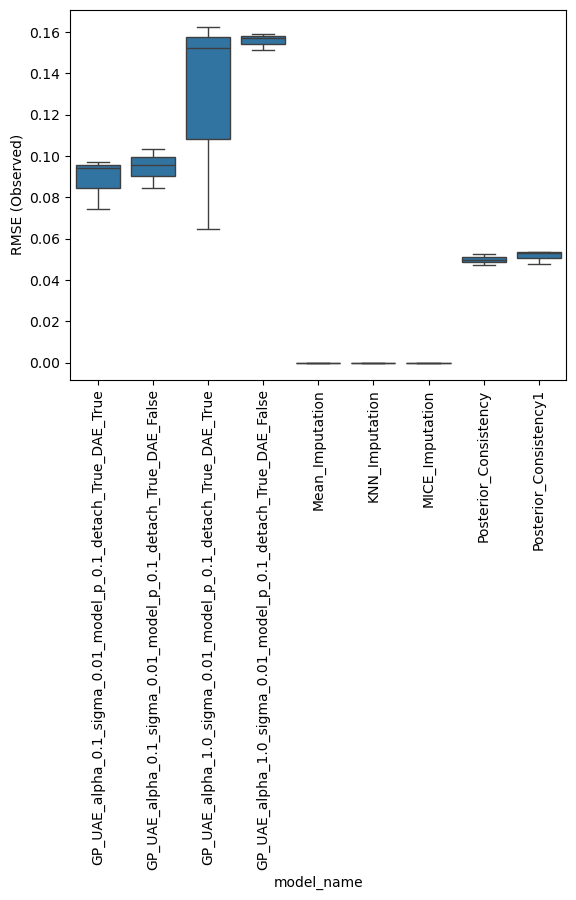

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

metric = 'RMSE (Observed)'

sns.boxplot(df[df.dataset_missingness == 0.3],
            x = 'model_name',
            y = metric)
#plt.yscale('log')
plt.xticks(rotation=90);